# Data-driven trajectory-manifold control

This notebook is the primary debug and results view for the end-to-end experiment in
`scripts/run_inverted_pendulum_mc.py`. Expensive collection, training, and closed-loop
optimization run in that script; this notebook loads the resulting artifacts.

Following *Trajectory Manifolds for Nonlinear Data-Enabled Predictive Control, Part I*,
the terminal-state-augmented behavior is

$$

\mathcal B_N^+=\{w=\operatorname{col}(\mathbf u,\mathbf x):x_{k+1}=f(x_k,u_k)\},
\quad q=\operatorname{col}(x_0,\mathbf u),
\quad w=\Phi_N(q).

$$

The learned decoder implements this canonical chart directly. It passes the measured
initial state and proposed inputs through exactly, and predicts future states using a
transition learned only from trajectory samples. The online controller does not call the
simulated plant model. A local terminal policy is also identified from trajectory data.

## Load artifacts and reproduce configuration


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

summary_path = project_root / "saves/simulation_results/canonical_manifold_dev.json"
results_path = project_root / "saves/simulation_results/canonical_manifold_dev.npz"
data_path = project_root / "saves/datasets/canonical_trajectories_dev.npz"
checkpoint_path = project_root / "saves/saved_models/canonical_decoder_dev.pt"

summary = json.loads(summary_path.read_text(encoding="utf-8"))
results = np.load(results_path)
dataset = np.load(data_path)
summary["config"]

{'horizon': 30,
 'dt': 0.0626418390534633,
 'episodes': 3500,
 'epochs': 100,
 'batch_size': 2048,
 'hidden_dims': [192, 192, 192],
 'umax': 10.0,
 'seed': 234,
 'simulation_seconds': 14.0,
 'controller_iterations': 60,
 'controller_lr': 0.06,
 'device': 'cuda'}

## Data provenance, episode split, and coverage


episode split: {'test': 525, 'validation': 525, 'train': 2450}
state coverage min: [ -9.87691689  -6.42387962 -10.70831203  -7.34106588]
state coverage max: [ 9.30788136  7.94741297 10.51183605  7.37320566]
input coverage: -10.0 10.0


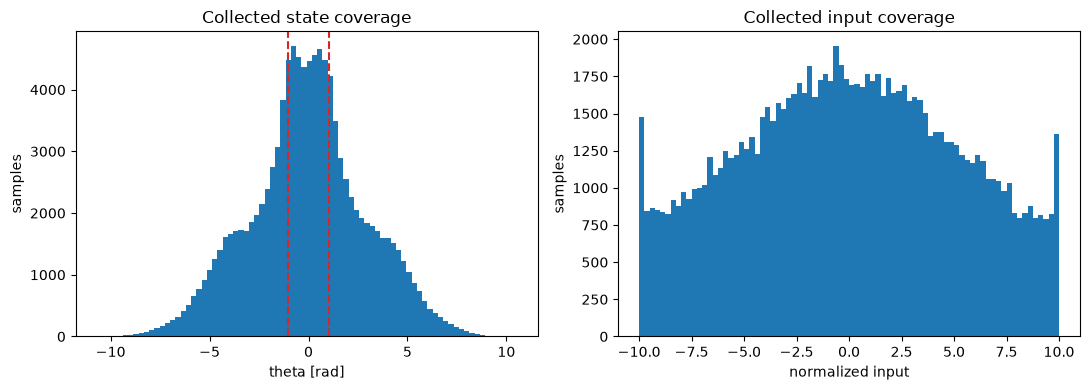

In [2]:
X_data, U_data = dataset["X"], dataset["U"]
print("episode split:", summary["split_sizes"])
print("state coverage min:", np.array(summary["coverage_min"]))
print("state coverage max:", np.array(summary["coverage_max"]))
print("input coverage:", float(U_data.min()), float(U_data.max()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(X_data[:, :, 2].ravel(), bins=80)
axes[0].axvline(np.pi / 3, color="tab:red", linestyle="--")
axes[0].axvline(-np.pi / 3, color="tab:red", linestyle="--")
axes[0].set(xlabel="theta [rad]", ylabel="samples", title="Collected state coverage")
axes[1].hist(U_data.ravel(), bins=80)
axes[1].set(xlabel="normalized input", ylabel="samples", title="Collected input coverage")
plt.tight_layout()

## Training history and held-out rollout error


{'mae_by_state': [0.010323080234229565,
  0.014940100722014904,
  0.01814706064760685,
  0.028155243024230003],
 'p95_by_state': [0.0391940101981163,
  0.04878517985343933,
  0.06788601726293564,
  0.09589125961065292],
 'final_p95_by_state': [0.06586799770593643,
  0.09466332942247391,
  0.1392943412065506,
  0.21509018540382385],
 'rmse_by_step': [0.0,
  0.004360498860478401,
  0.00760314054787159,
  0.010090409778058529,
  0.011539663188159466,
  0.012650476768612862,
  0.013783103786408901,
  0.014909139834344387,
  0.016222376376390457,
  0.017627840861678123,
  0.018986254930496216,
  0.02019745111465454,
  0.02158346399664879,
  0.023362670093774796,
  0.025334520265460014,
  0.02725181169807911,
  0.02881176955997944,
  0.030592966824769974,
  0.032161787152290344,
  0.03393418341875076,
  0.03576797991991043,
  0.03717493265867233,
  0.038712434470653534,
  0.04040556028485298,
  0.04225478693842888,
  0.04494493827223778,
  0.04946340620517731,
  0.0542282909154892,
  0.05907

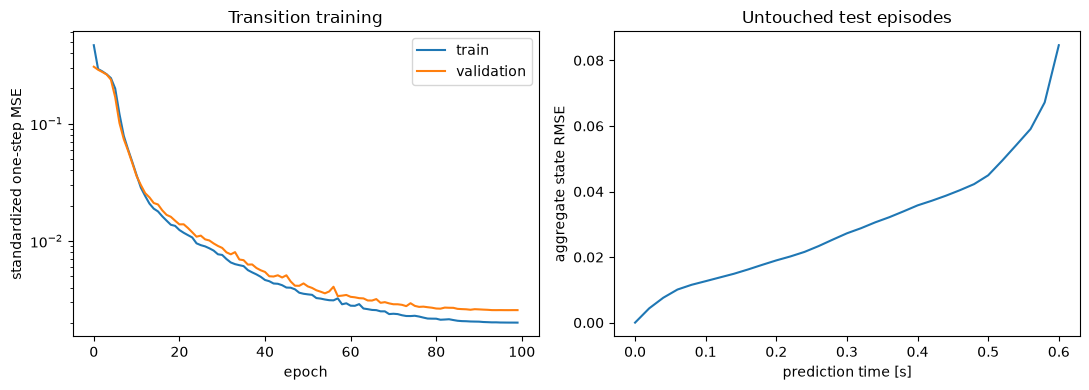

In [3]:
history = summary["training_history"]
rollout_rmse = summary["prediction_metrics"]["rmse_by_step"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(history["train"], label="train")
axes[0].semilogy(history["validation"], label="validation")
axes[0].set(xlabel="epoch", ylabel="standardized one-step MSE", title="Transition training")
axes[0].legend()
axes[1].plot(np.arange(len(rollout_rmse)) * 0.02, rollout_rmse)
axes[1].set(xlabel="prediction time [s]", ylabel="aggregate state RMSE",
            title="Untouched test episodes")
plt.tight_layout()
summary["prediction_metrics"]

## Decoder structural checks


In [4]:
from scripts.run_inverted_pendulum_mc import load_transition
from src.manifold_control import CanonicalBehaviorDecoder

transition, payload = load_transition(checkpoint_path, summary["config"]["device"])
decoder = CanonicalBehaviorDecoder(transition, summary["config"]["horizon"]).eval()
device = next(decoder.parameters()).device
x0 = torch.tensor([0.1, -0.2, 0.3, -0.4], device=device)
u = torch.linspace(-1, 1, decoder.horizon, device=device).reshape(-1, 1)
q = decoder.coordinates(x0, u)
x_decoded, u_decoded = decoder.unpack_behavior(decoder(q))
assert torch.equal(x_decoded[0], x0)
assert torch.equal(u_decoded, u)
print("q dimension:", decoder.alpha_dim)
print("w dimension:", decoder.w_dim)
print("exact x0/input passthrough: passed")

q dimension: 34
w dimension: 154
exact x0/input passthrough: passed


## Closed-loop results and checkpoints


theta0_-60deg {'balanced': True, 'cart_rest': False, 'final_theta': -0.0010803011077399414, 'final_theta_dot_physical': 0.00032171744020580075, 'final_x_dot_physical': 0.03541028015632479, 'max_abs_u': 10.0, 'max_abs_theta': 1.0471975511965976}
theta0_-30deg {'balanced': True, 'cart_rest': False, 'final_theta': -0.0006263263677447662, 'final_theta_dot_physical': 0.00018641651673235107, 'final_x_dot_physical': 0.02053231859046969, 'max_abs_u': 8.576868057250977, 'max_abs_theta': 0.5235987755982988}
theta0_-15deg {'balanced': True, 'cart_rest': True, 'final_theta': -0.00010203211440147313, 'final_theta_dot_physical': 3.036891981389197e-05, 'final_x_dot_physical': 0.0033448158579416055, 'max_abs_u': 6.222354412078857, 'max_abs_theta': 0.2617993877991494}
theta0_+15deg {'balanced': True, 'cart_rest': True, 'final_theta': 0.00016954215978928257, 'final_theta_dot_physical': -5.046247482658858e-05, 'final_x_dot_physical': -0.005557934081697343, 'max_abs_u': 5.788150805537519, 'max_abs_theta':

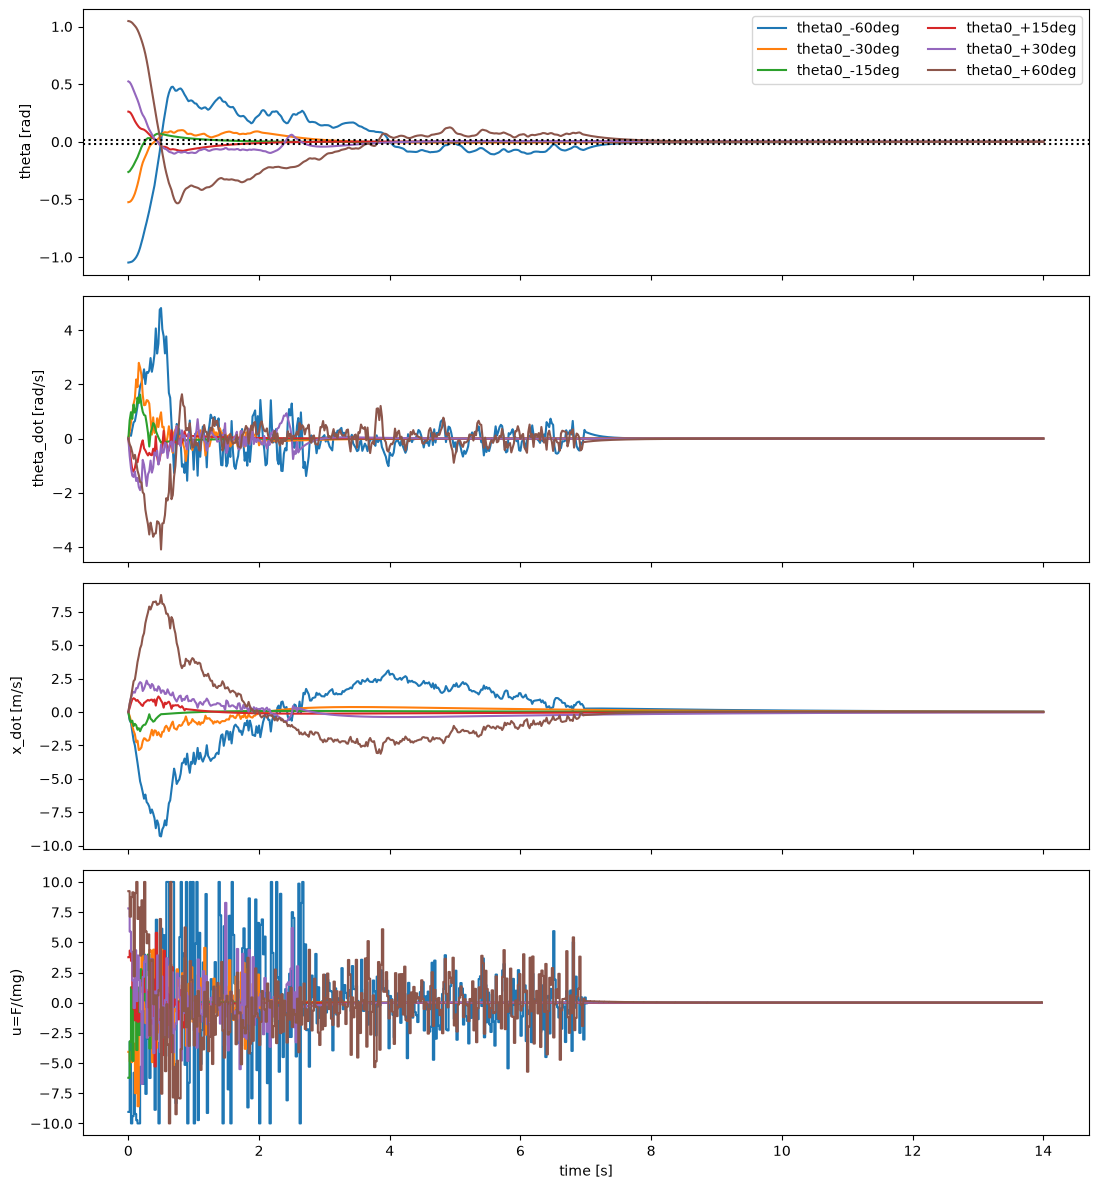

In [5]:
metrics = summary["closed_loop_metrics"]
for case, values in metrics.items():
    print(case, values)

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
for case in metrics:
    t = results[f"t_{case}"]
    X = results[f"X_{case}"]
    U = results[f"U_{case}"]
    axes[0].plot(t, X[:, 2], label=case)
    axes[1].plot(t, X[:, 3] * math.sqrt(9.81), label=case)
    axes[2].plot(t, X[:, 1] * math.sqrt(9.81), label=case)
    axes[3].step(t[:-1], U[:, 0], where="post", label=case)
axes[0].axhline(0.02, color="black", linestyle=":")
axes[0].axhline(-0.02, color="black", linestyle=":")
for axis, label in zip(axes, ("theta [rad]", "theta_dot [rad/s]", "x_dot [m/s]", "u=F/(mg)")):
    axis.set_ylabel(label)
axes[3].set_xlabel("time [s]")
axes[0].legend(ncol=2)
plt.tight_layout()

## Solver timing and terminal-policy usage


In [6]:
diagnostics = summary["solver_diagnostics"]
for case, values in diagnostics.items():
    solve_time = np.asarray(values["solve_seconds"])
    terminal = np.asarray(values["terminal_policy_used"], dtype=bool)
    print(f"{case}: manifold solves={len(solve_time)}, median={np.median(solve_time):.4f}s, "
          f"terminal-policy fraction={terminal.mean():.3f}")

theta0_-60deg: manifold solves=70, median=0.0679s, terminal-policy fraction=0.504
theta0_-30deg: manifold solves=21, median=0.0705s, terminal-policy fraction=0.859
theta0_-15deg: manifold solves=6, median=0.0671s, terminal-policy fraction=0.967
theta0_+15deg: manifold solves=9, median=0.0675s, terminal-policy fraction=0.943
theta0_+30deg: manifold solves=29, median=0.0682s, terminal-policy fraction=0.829
theta0_+60deg: manifold solves=70, median=0.0682s, terminal-policy fraction=0.506


## Existing pendulum animation


In [11]:
from IPython.display import HTML
from src.plotting import animate_point_mass

case = "theta0_+60deg"
t = results[f"t_{case}"]
X = results[f"X_{case}"]
U = results[f"U_{case}"][:, 0]
animation = animate_point_mass(t[:-1], X[:-1, 0], X[:-1, 2], 1.0, U, case_name=case, frame_step=5)
HTML(animation.to_jshtml())

## Interpretation and limitations

- The reported controller is fully data-driven: its rollout decoder, local terminal model,
  and feedback gain are fitted from measured trajectories. The plant equations are used only
  to create the simulated experiment and score the resulting controller.
- All six staged initial angles from -60 to +60 degrees satisfy the angular residence test in
  the saved 14-second experiment. Cart rest is reported separately.
- Input saturation is active for the large-angle cases. These outcomes establish empirical
  performance on the tested simulation and seed; they are not a closed-loop stability proof.
- The 30-step test-rollout error grows with horizon. Optimizer-selected trajectory validation,
  additional seeds, disturbances, and transfer to a different plant remain useful next checks.